# Manifold Learning: t-SNE and UMAP for Equity Return

This notebook explores how [t-SNE](https://lvdmaaten.github.io/tsne/) and UMAP perform on equity returns.

## Imports & Settings

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

In [2]:
sns.set_style('white')
np.random.seed(42)

## Load equity returns

This example uses daily returns; remove the comment symbols to use weekly returns instead.

In [3]:
idx = pd.IndexSlice
with pd.HDFStore('../../data/assets.h5') as store:
    returns = (store['quandl/wiki/prices']
               .loc[idx['2000':'2018', :], 'adj_close']
               .unstack('ticker')
#                .resample('W')
#                .last()
               .pct_change())

C:\Users\paxto\AppData\Local\Temp\ipykernel_92368\898024795.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change())


In [4]:
returns = returns.dropna(thresh=int(returns.shape[0] * .95), axis=1)
returns = returns.dropna(thresh=int(returns.shape[1] * .95)).clip(lower=-.5, upper=.5)
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4705 entries, 2000-01-04 to 2018-03-27
Columns: 1886 entries, A to ZQK
dtypes: float64(1886)
memory usage: 67.7 MB


In [5]:
returns = returns.sample(n=250)
daily_avg = returns.mean(1)
returns = returns.apply(lambda x: x.fillna(daily_avg))

In [6]:
pca = PCA(n_components=2)

## T-Stochastic Neighbor Embedding (TSNE): Parameter Settings

### Perplexity: emphasis on local vs global structure

In [7]:
n_iter = 5000

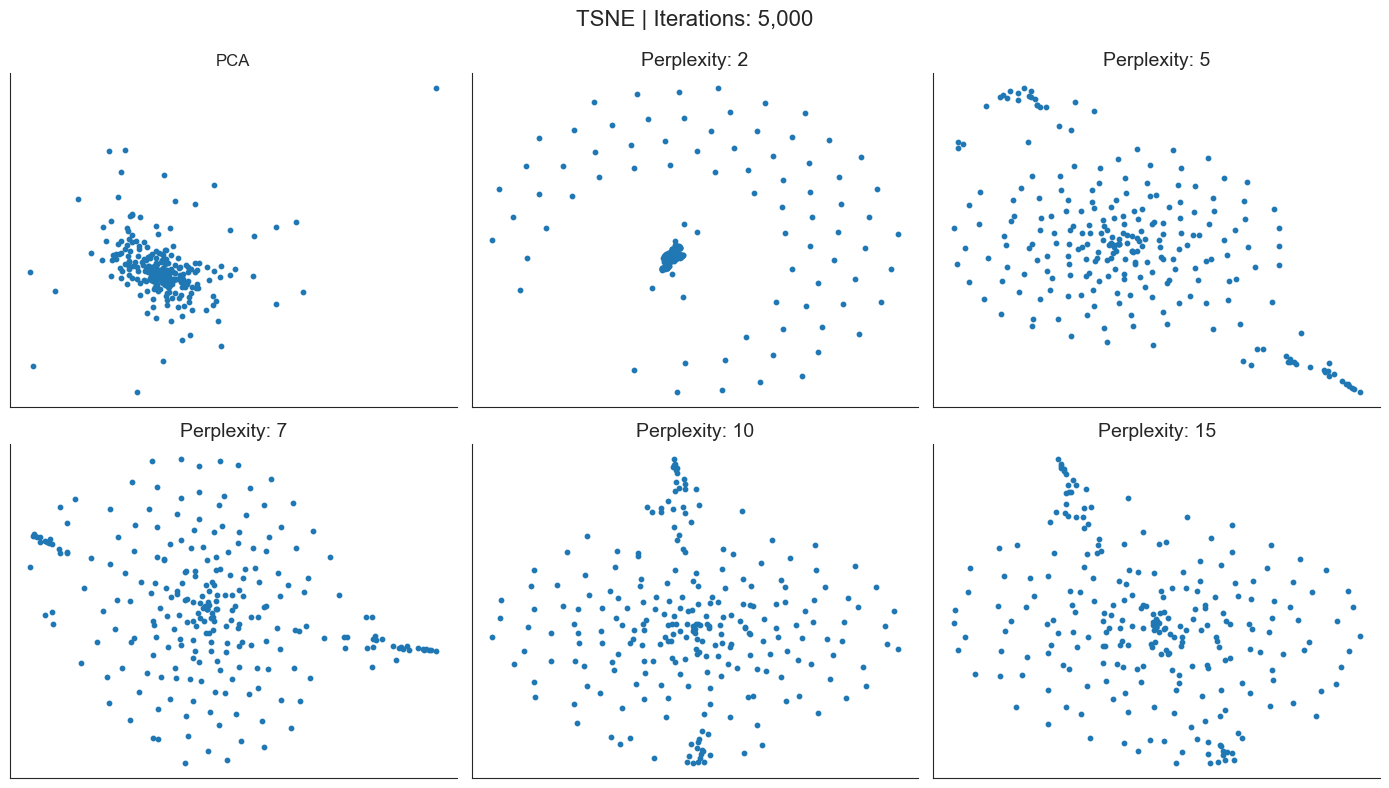

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()

axes[0].scatter(*pca.fit_transform(returns).T, s=10)
axes[0].set_title('PCA')
axes[0].axes.get_xaxis().set_visible(False)
axes[0].axes.get_yaxis().set_visible(False)

for i, p in enumerate([2, 5, 7, 10, 15], 1):
    embedding = TSNE(perplexity=p,
                     max_iter=n_iter).fit_transform(returns)
    axes[i].scatter(embedding[:, 0], embedding[:, 1], s=10)
    axes[i].set_title('Perplexity: {:.0f}'.format(p), fontsize=14)
    axes[i].axes.get_xaxis().set_visible(False)
    axes[i].axes.get_yaxis().set_visible(False)

fig.suptitle(f'TSNE | Iterations: {n_iter:,.0f}', fontsize=16)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.9)

### Convergence with `n_iter`

In [9]:
perplexity = 5

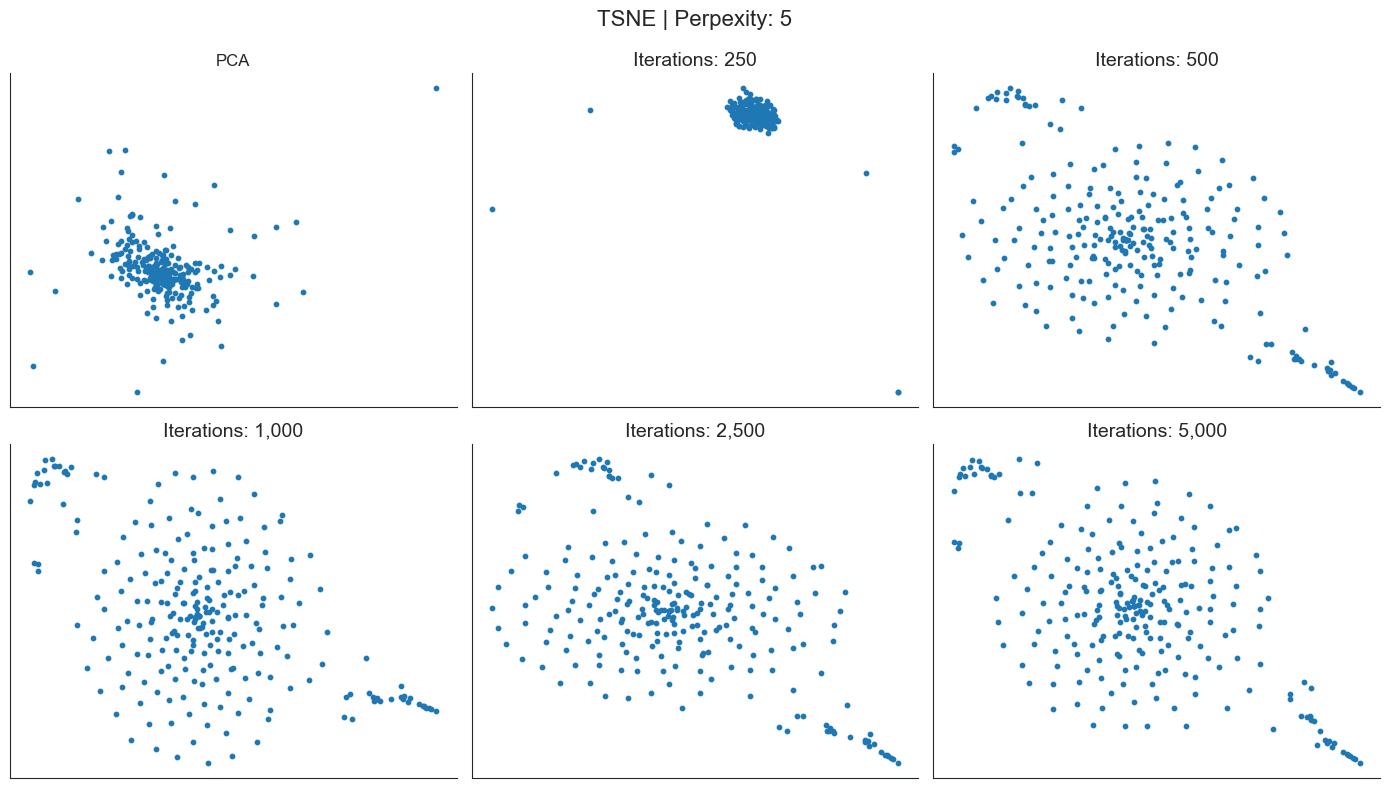

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()
axes[0].scatter(*pca.fit_transform(returns).T, s=10)
axes[0].set_title('PCA')
axes[0].axes.get_xaxis().set_visible(False)
axes[0].axes.get_yaxis().set_visible(False)

for i, n in enumerate([250, 500, 1000, 2500, 5000], 1):
    embedding = TSNE(perplexity=perplexity, 
                     max_iter=n).fit_transform(returns)
    axes[i].scatter(embedding[:, 0], embedding[:, 1], s=10)
    axes[i].set_title('Iterations: {:,.0f}'.format(n), fontsize=14)
    axes[i].axes.get_xaxis().set_visible(False)
    axes[i].axes.get_yaxis().set_visible(False)

fig.suptitle(f'TSNE | Perpexity: {perplexity:,.0f}', fontsize=16)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.9)

## Uniform Manifold Approximation and Projection (UMAP): Parameter Settings

### Neighbors

In [11]:
min_dist = .1

c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 

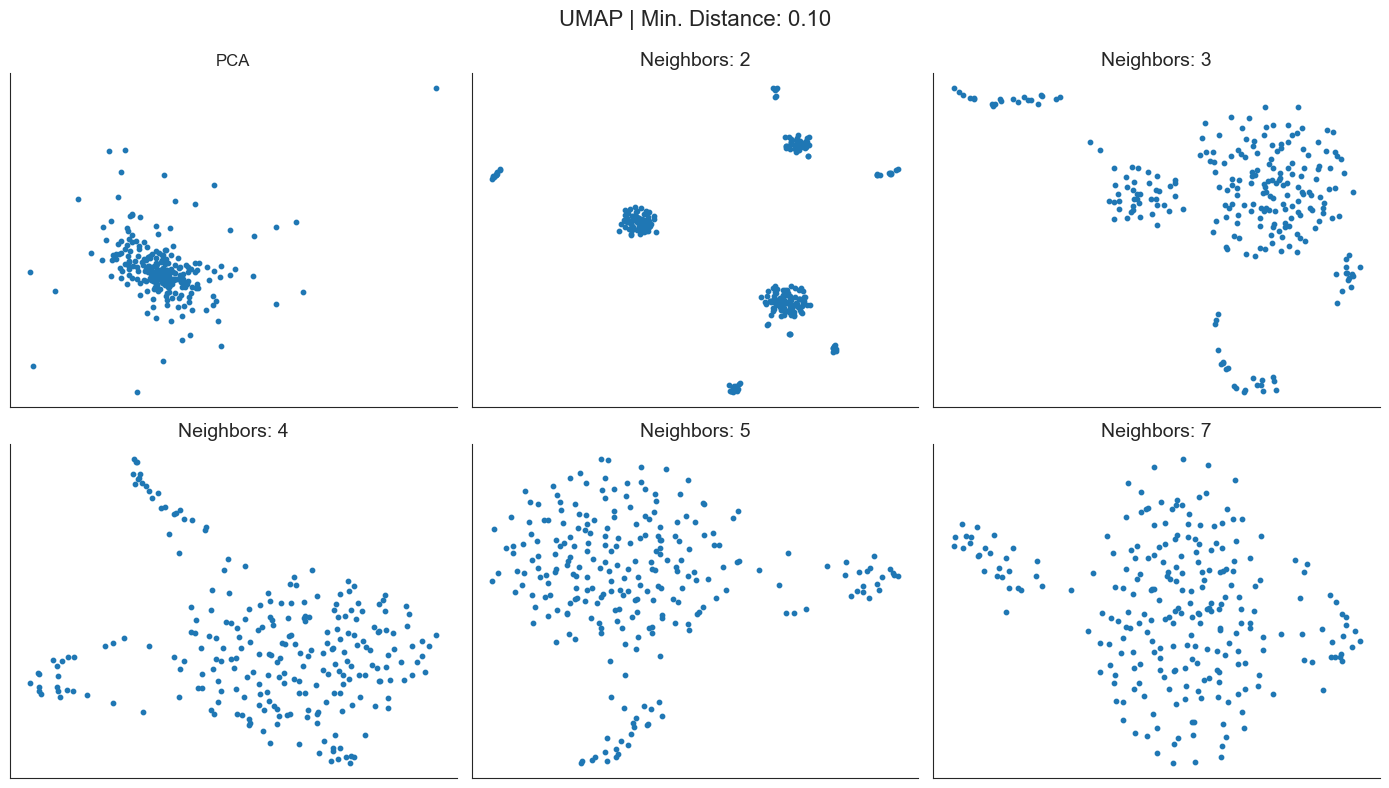

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()

axes[0].scatter(*pca.fit_transform(returns).T, s=10)
axes[0].set_title('PCA')
axes[0].axes.get_xaxis().set_visible(False)
axes[0].axes.get_yaxis().set_visible(False)

for i, n in enumerate([2, 3, 4, 5, 7], 1):
    embedding = umap.UMAP(n_neighbors=n, 
                          min_dist=min_dist).fit_transform(returns)
    axes[i].scatter(embedding[:, 0], embedding[:, 1], s=10)
    axes[i].set_title('Neighbors: {:.0f}'.format(n), fontsize=14)
    axes[i].axes.get_xaxis().set_visible(False)
    axes[i].axes.get_yaxis().set_visible(False)
    
fig.suptitle(f'UMAP | Min. Distance: {min_dist:,.2f}', fontsize=16)    
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.9)

### Minimum Distance

In [13]:
n_neighbors = 2

c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 

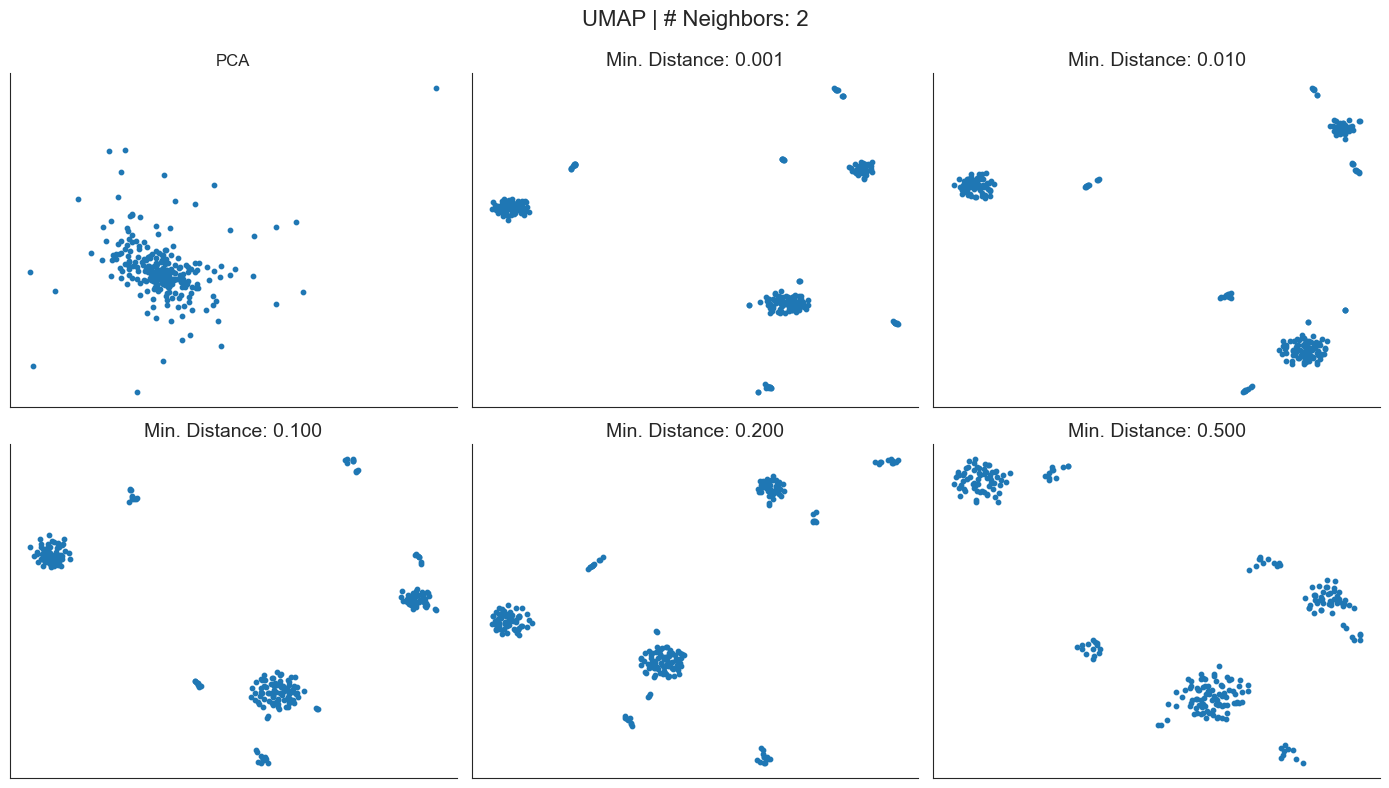

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14,8))
axes = axes.flatten()

axes[0].scatter(*pca.fit_transform(returns).T, s=10)
axes[0].set_title('PCA')
axes[0].axes.get_xaxis().set_visible(False)
axes[0].axes.get_yaxis().set_visible(False)

for i, d in enumerate([.001, .01, .1, .2, .5], 1):
    embedding = umap.UMAP(n_neighbors=n_neighbors, 
                          min_dist=d).fit_transform(returns)
    axes[i].scatter(embedding[:, 0], embedding[:, 1], s=10)
    axes[i].set_title('Min. Distance: {:.3f}'.format(d), fontsize=14)
    axes[i].axes.get_xaxis().set_visible(False)
    axes[i].axes.get_yaxis().set_visible(False)

    
fig.suptitle(f'UMAP | # Neighbors: {n_neighbors:,.0f}', fontsize=16)    
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.9)